In [2]:
import quimb as qu
import quimb.tensor as qtn
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from circuit_generation import *
from tree_class import *
from best_mps_ordering import local_greedy_swap, greedy_weighted_linear_arrangement, plot_graph_comparisons

In [80]:
N_qubits = 10
N_gates = 4
max_bond = None

circ = generate_random_circuit(num_qubits=N_qubits,num_gates=N_gates,plot=False)

G, mst, adj = plot_connectivity_and_max_mst(circ, return_adjacency_matrix=True)

## from the graph we derive the best permutation for the MPS 
perm = greedy_weighted_linear_arrangement(G)
initial_order = greedy_weighted_linear_arrangement(G)
perm, final_cost = local_greedy_swap(G, initial_order)

# perm = [2,0,1]
perm = {i: q for i, q in enumerate(perm)}
inverse_perm = {perm[q]:q for q in perm.keys()}

perm,inverse_perm

({0: 1, 1: 2, 2: 9, 3: 8, 4: 3, 5: 7, 6: 0, 7: 4, 8: 5, 9: 6},
 {1: 0, 2: 1, 9: 2, 8: 3, 3: 4, 7: 5, 0: 6, 4: 7, 5: 8, 6: 9})

In [ ]:
mps_ordered = qtn.CircuitMPS(N_qubits)

for gate in circ.gates:
    qubits = gate.qubits  # par exemple (2,) ou (0, 1)
    remapped_qubits = tuple(inverse_perm[q] for q in gate.qubits)

    # mps.apply_gate(gate)
    new_gate = gate.copy()
    new_gate.qubits = np.int64(remapped_qubits)
    mps_ordered.apply_gate(new_gate)

dic = {'k'+str(i): 'k'+str(perm[i]) for i in perm.keys()}
mps_unperm = mps_ordered.psi.reindex(dic)
net = circ.psi.H & mps_unperm
net.contract()

(0.29231684581317735+0j)

In [ ]:
import quimb as qu
import quimb.tensor as qtn
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from circuit_generation import *
from tree_class import *
from best_mps_ordering import local_greedy_swap, greedy_weighted_linear_arrangement, plot_graph_comparisons

def test_tree_mps(circ,n_qb = 10,max_bond=None,return_memory=False, plot = False):
    G, mst, adj = plot_connectivity_and_max_mst(circ, return_adjacency_matrix=True)

    # permuted MPS

        # derive 'best' permutation from the graph
    perm = greedy_weighted_linear_arrangement(G)
    initial_order = greedy_weighted_linear_arrangement(G)
    perm, final_cost = local_greedy_swap(G, initial_order)

    perm = {i: q for i, q in enumerate(perm)}
        # reverse the permutation for a good mapping of the gates
    # inverse_perm = {'k'+str(i): 'k'+str(perm[i]) for i in perm.keys()}
    inverse_perm = {perm[q]:q for q in perm.keys()}


    # print('--------')
    # print(n_qb)
    # print(perm)
    # print(inverse_perm)

    mps_ordered = qtn.CircuitMPS(n_qb,max_bond=max_bond)
    for gate in circ.gates:
        qubits = gate.qubits  # par exemple (2,) ou (0, 1)
        remapped_qubits = tuple(inverse_perm[q] for q in gate.qubits)

        # mps.apply_gate(gate)
        new_gate = gate.copy()
        new_gate.qubits = np.int64(remapped_qubits)
        mps_ordered.apply_gate(new_gate)

    # reverse effect of permutation
    reindex_dic_ordered = {'k'+str(i): 'k'+str(perm[i]) for i in perm.keys()}
    mps_unperm = mps_ordered.psi.reindex(reindex_dic_ordered)

    if plot : 
        plot_graph_comparisons(G, initial_order, perm)

    # non reordered mps-------------------------------
    mps = qtn.CircuitMPS(n_qb,max_bond=max_bond)
    for gate in circ.gates:
        mps.apply_gate(gate)
    mps_net = mps.psi.contract()
    
    # Tree -------------------------------------------


    tree,trad_dic = tree_from_matrix(adj,0,max_bond=max_bond)
    tree = replicate_circ(circ,tree,trad_dic)

    reindex_dic = {'k'+str(k): 'out'+ str(v) for k, v in trad_dic.items()}
    circ_net_reindexed = circ.psi.reindex_(reindex_dic).contract().H
    tree_net = tree.network.contract()

    # Compute fidelity to original circuit
    circ_net = circ.psi.contract().H

    fnet = circ_net_reindexed & tree_net
    fnetMPS = circ_net & mps_net
    fnetMPSordered = circ_net & mps_unperm
    
    fidelity_tree = np.abs(fnet.contract())
    fidelity_mps = np.abs(fnetMPS.contract())
    fidelity_mps_ordered = np.abs(fnetMPSordered.contract())

    if return_memory:
        mem_tree = sum(t.size for t in tree.network)
        mem_mps = sum(t.size for t in mps.psi)
        mem_omps = sum(t.size for t in mps_ordered.psi)

        return(fidelity_tree,fidelity_mps,fidelity_mps_ordered, mem_tree,mem_mps, mem_omps)
    
    return(fidelity_tree, fidelity_mps, fidelity_mps_ordered)

def replicate_circ(circ,tree,trad_dic):
    
    for gate in circ.gates:
        if gate.label == 'RX':
            param = gate.params[0]
            qubit = trad_dic[gate.qubits[0]]
            tree.apply_1qb_gate(i = qubit,gate_array=gate.build_array())

        if gate.label == 'CNOT':
            qubit_1 = trad_dic[gate.qubits[0]]
            qubit_2 = trad_dic[gate.qubits[1]]
            tree.apply_2qb_gate(i = qubit_1,j = qubit_2,gate_array=gate.build_array().reshape(2,2,2,2))
    return tree


# --------------------------------------------------------------------------------------------------

tree_fidelity_values = []
mps_fidelity_values = []
mps_ordered_fidelity_values = []
diff_values = []
delta_mps = []

# chi_range = range(1,40,3) 
# N_gate_range = range(10,200,30)
chi_range = range(1,40,3) 
N_gate_range = range(10,200,30)
nb_moy = 10

results = []
chi_tree_moy_dic = {}
chi_mps_moy_dic = {}
chi_omps_moy_dic = {}

mem_tree_moy_dic = {}
mem_mps_moy_dic = {}
mem_omps_moy_dic = {}
  
N_qubits = 5

for N in tqdm(N_gate_range):
    for chi in chi_range:
        chi_mps_moy_dic[chi] = []
        chi_omps_moy_dic[chi] = []
        chi_tree_moy_dic[chi] = []
        mem_tree_moy_dic[chi] = []
        mem_mps_moy_dic[chi] = []
        mem_omps_moy_dic[chi] = []

    for i in range(nb_moy):
        circ = generate_random_circuit(num_qubits=N_qubits,num_gates=N,plot=False)

        for chi in chi_range:
            tree_fidelity,mps_fidelity,omps_fidelity,mem_tree,mem_mps,mem_omps = test_tree_mps(circ = circ,n_qb=N_qubits,max_bond=chi,return_memory=True)
            chi_tree_moy_dic[chi].append(tree_fidelity)
            chi_mps_moy_dic[chi].append(mps_fidelity)
            chi_omps_moy_dic[chi].append(omps_fidelity)
            mem_tree_moy_dic[chi].append(mem_tree)
            mem_mps_moy_dic[chi].append(mem_mps)
            mem_omps_moy_dic[chi].append(mem_omps)

    
    for chi in chi_range:
        results.append((N,chi,np.mean(chi_tree_moy_dic[chi]),np.mean(chi_mps_moy_dic[chi]), np.mean(chi_omps_moy_dic[chi]),np.mean(mem_tree_moy_dic[chi]),np.mean(mem_mps_moy_dic[chi]),np.mean(mem_omps_moy_dic[chi])))

  0%|          | 0/7 [00:00<?, ?it/s]

 86%|████████▌ | 6/7 [08:15<01:50, 110.58s/it]

In [ ]:
np.savetxt('results.txt',results)

Text(0.5, 0, 'fidelity difference for MPS')

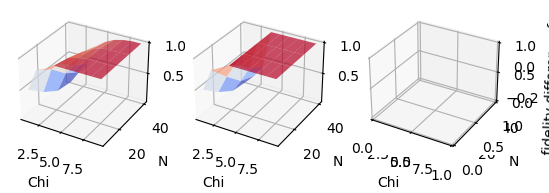

In [92]:
# np.savetxt('results.txt',results)


N,CHI,RES_tree,RES_mps, RES_mps_ordered = zip(*results)
# RES = np.array(RES).reshape(len(N),len(CHI))
N = np.array(N).reshape(len(N_gate_range),len(chi_range))
CHI = np.array(CHI).reshape(len(N_gate_range),len(chi_range))
RES_tree = np.array(RES_tree).reshape(len(N_gate_range),len(chi_range))
RES_mps = np.array(RES_mps).reshape(len(N_gate_range),len(chi_range))
RES_mps_ordered = np.array(RES_mps).reshape(len(N_gate_range),len(chi_range))

RES_diff = np.subtract(RES_tree,RES_mps)
RES_delta_mps = np.subtract(RES_mps_ordered,RES_mps)
fig = plt.figure()

###
ax1 = fig.add_subplot(131, projection='3d')
ax1.plot_surface(CHI, N, RES_tree, alpha = 0.7,cmap='coolwarm')

# ax.contour(CHI, N, RES, zdir='x', offset=-15, cmap='coolwarm')
# ax.contour(CHI, N, RES, zdir='y', offset=500, cmap='coolwarm')

ax1.set_xlabel('Chi')
ax1.set_ylabel('N')
ax1.set_zlabel('fidelity tree')


###
ax2 = fig.add_subplot(132, projection='3d')
ax2.plot_surface(CHI, N, RES_mps, alpha = 0.7,cmap='coolwarm')

# ax.contour(CHI, N, RES, zdir='x', offset=-15, cmap='coolwarm')
# ax.contour(CHI, N, RES, zdir='y', offset=500, cmap='coolwarm')

ax2.set_xlabel('Chi')
ax2.set_ylabel('N')
ax2.set_zlabel('fidelity mps')

###

ax2 = fig.add_subplot(133, projection='3d')
ax2.plot_surface(CHI, N, RES_diff, alpha = 0.7,cmap='coolwarm')

# ax.contour(CHI, N, RES, zdir='x', offset=-15, cmap='coolwarm')
# ax.contour(CHI, N, RES, zdir='y', offset=500, cmap='coolwarm')

ax2.set_xlabel('Chi')
ax2.set_ylabel('N')
ax2.set_zlabel('fidelity diff')

ax3 = fig.add_subplot(133, projection='3d')
ax2.plot_surface(CHI, N, RES_delta_mps, alpha = 0.7,cmap='coolwarm')

# ax.contour(CHI, N, RES, zdir='x', offset=-15, cmap='coolwarm')
# ax.contour(CHI, N, RES, zdir='y', offset=500, cmap='coolwarm')

ax2.set_xlabel('Chi')
ax2.set_ylabel('N')
ax2.set_zlabel('fidelity difference for MPS')